<a href="https://colab.research.google.com/github/tmtngu/BTVN_AI_1/blob/main/Nh%E1%BA%ADn_Di%E1%BB%87n_IC0001_K51.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import tensorflow as tf

duong_dan="/content/drive/MyDrive/AI CÁ NHÂN"
chieu_dai_anh,chieu_cao_anh=224,224
kich_thuoc_goi=32

train=tf.keras.utils.image_dataset_from_directory(
    duong_dan,
    labels='inferred',
    label_mode='categorical',
    image_size=(chieu_dai_anh,chieu_cao_anh),
    batch_size=kich_thuoc_goi,
    validation_split=0.2,
    subset='training',
    seed=123,
    crop_to_aspect_ratio=True)

ho_ten=train.class_names

test=tf.keras.utils.image_dataset_from_directory(
    duong_dan,
    labels='inferred',
    label_mode='categorical',
    image_size=(chieu_dai_anh,chieu_cao_anh),
    batch_size=kich_thuoc_goi,
    validation_split=0.2,
    subset='validation',
    seed=123,
    crop_to_aspect_ratio=True)

chuan_hoa=tf.keras.layers.Rescaling(1./255)
toi_uu=tf.data.AUTOTUNE

train=train.map(lambda x,y:(chuan_hoa(x),y)).cache().shuffle(1000).prefetch(buffer_size=toi_uu)
test=test.map(lambda x,y:(chuan_hoa(x),y)).cache().prefetch(buffer_size=toi_uu)

Found 1896 files belonging to 34 classes.
Using 1517 files for training.
Found 1896 files belonging to 34 classes.
Using 379 files for validation.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt

so_nguoi=34
model=Sequential()

model.add(RandomFlip("horizontal",input_shape=(chieu_dai_anh,chieu_cao_anh,3)))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))

model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(so_nguoi, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 34)             │         8,738 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,244,386 (50.52 MB)

 Trainable params: 13,243,426 (50.52 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 155s 790ms/step - accuracy: 0.3626 - loss: 2.6349 - val_accuracy: 0.0264 - val_loss: 4.8747
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 57s 138ms/step - accuracy: 0.6730 - loss: 1.1761 - val_accuracy: 0.0554 - val_loss: 7.6459
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.7726 - loss: 0.7502 - val_accuracy: 0.0554 - val_loss: 12.6973
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.8497 - loss: 0.5284 - val_accuracy: 0.0554 - val_loss: 14.7555
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.8748 - loss: 0.4146 - val_accuracy: 0.0792 - val_loss: 14.3142
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.8866 - loss: 0.3958 - val_accuracy: 0.0554 - val_loss: 17.5391
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.9156 - loss: 0.2792 - val_accuracy: 0.0633 - val_loss: 16.1362
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.9202 - loss: 0.2718 - val_accu

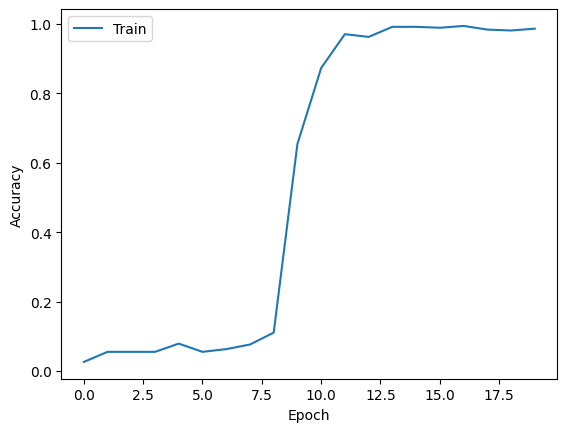

In [14]:
history=model.fit(
    train,
    epochs=20,
    validation_data=test)
plt.plot(history.history['val_accuracy'],label='ket qua')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()
model.save("/content/filetrainnhandienmattmt.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Đây là Trịnh Minh Thiên


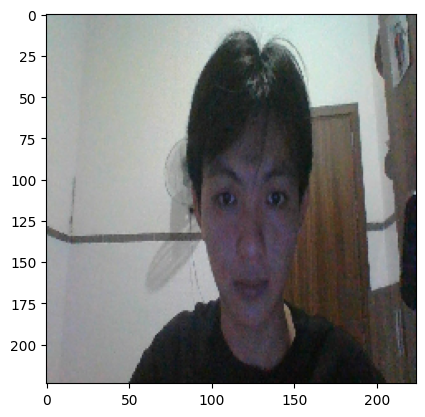

In [18]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path="/content/WIN_20260602_15_51_12_Pro.jpg"
img=load_img(path,target_size=(chieu_dai_anh,chieu_cao_anh))
plt.imshow(img)
img=np.array(img)
img=img/255.0
img=img.reshape(1,chieu_dai_anh,chieu_cao_anh,3)

pred=np.argmax(model.predict(img))

ten=ho_ten[pred]
print(f"Đây là {ten}")